# Restaurant or Product Review Sentiment Classifier
This notebook builds a sentiment analysis pipeline for review text. The goal is to classify customer reviews as positive or negative after removing neutral ratings. The project compares model performance across Logistic Regression, Multinomial Naive Bayes, and a feedforward Artificial Neural Network (ANN).


In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df=pd.read_csv('Reviews.csv')
print('Shape:', df.shape)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Score distribution:')
print(df['Score'].value_counts().sort_index())
print()
df.head()

Shape: (568454, 10)

Missing values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Score distribution:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64



,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Data Loading and Exploration
The dataset is loaded from `Reviews.csv`, then examined for shape, missing values, and score distribution. Neutral reviews with score 3 are removed, and remaining ratings are converted to binary sentiment labels: positive for scores 4 and 5, negative for scores 1 and 2.


In [3]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 43.4 MB


In [5]:
df=df[df['Score']!=3] # Drop score = 3 (neutral — gives no clear signal)
# 4 or 5 stars → Positive (1)
# 1 or 2 stars → Negative (0)
df['Sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

In [6]:
df['Sentiment']

0         1
1         0
2         1
3         0
4         1
         ..
568449    1
568450    0
568451    1
568452    1
568453    1
Name: Sentiment, Length: 525814, dtype: int64

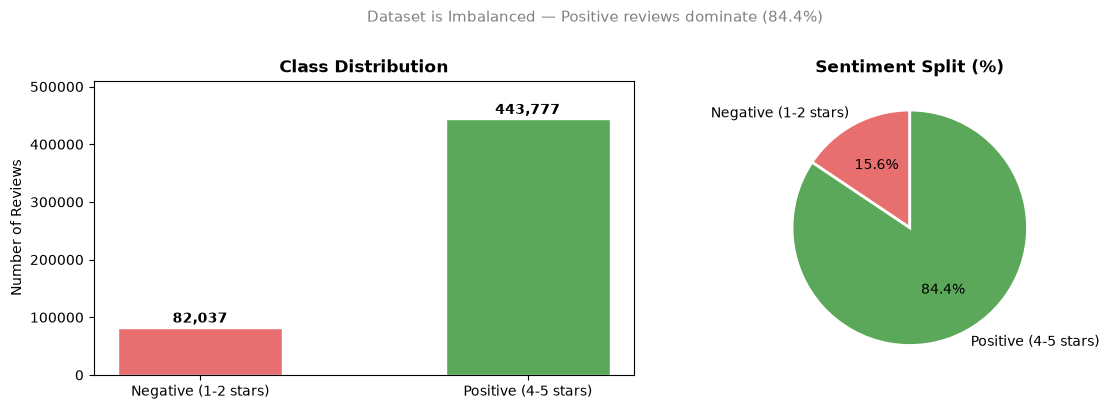

Note: Heavy class imbalance — will need class_weight handling during model training


In [7]:
counts = df['Sentiment'].value_counts().sort_index()
labels = ['Negative (1-2 stars)', 'Positive (4-5 stars)']
colors = ['#E76F6F', '#5BA85A']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Split (%)', fontweight='bold')

plt.suptitle('Dataset is Imbalanced — Positive reviews dominate (84.4%)',
             fontsize=11, color='gray', y=1.01)
plt.tight_layout()
plt.savefig('viz1_class_distribution.png', bbox_inches='tight')
plt.show()
print('Note: Heavy class imbalance — will need class_weight handling during model training')

In [8]:
import re
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
# # Word count per review
# df['word_count'] = df['Text'].apply(lambda x: len(str(x).split()))

# pos_wc = df[df['Sentiment'] == 1]['word_count']
# neg_wc = df[df['Sentiment'] == 0]['word_count']

# fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# # Histogram — capped at 300 words for readability
# axes[0].hist(pos_wc.clip(upper=300), bins=60, alpha=0.6,
#              color='#5BA85A', label='Positive', density=True)
# axes[0].hist(neg_wc.clip(upper=300), bins=60, alpha=0.6,
#              color='#E76F6F', label='Negative', density=True)
# axes[0].set_title('Review Length Distribution (capped at 300 words)', fontweight='bold')
# axes[0].set_xlabel('Word Count')
# axes[0].set_ylabel('Density')
# axes[0].legend()

# # Box plot
# data_to_plot = [pos_wc.clip(upper=300).values, neg_wc.clip(upper=300).values]
# bp = axes[1].boxplot(data_to_plot, patch_artist=True, widths=0.5,
#                      medianprops={'color': 'black', 'linewidth': 2})
# bp['boxes'][0].set_facecolor('#5BA85A')
# bp['boxes'][0].set_alpha(0.7)
# bp['boxes'][1].set_facecolor('#E76F6F')
# bp['boxes'][1].set_alpha(0.7)
# axes[1].set_xticks([1, 2])
# axes[1].set_xticklabels(['Positive', 'Negative'])
# axes[1].set_title('Word Count Spread by Sentiment', fontweight='bold')
# axes[1].set_ylabel('Word Count')

# # Add median labels
# for i, (label, data) in enumerate(zip(['Positive', 'Negative'], data_to_plot)):
#     median = int(np.median(data))
#     axes[1].text(i+1, median + 4, f'Median: {median}',
#                  ha='center', fontsize=9, color='black')

# plt.suptitle('Negative reviews tend to be slightly longer than positive ones',
#              fontsize=10, color='gray')
# plt.tight_layout()
# plt.savefig('viz3_review_length.png', bbox_inches='tight')
# plt.show()

# print(f'Positive — Mean: {pos_wc.mean():.1f} words | Median: {pos_wc.median():.0f} words')
# print(f'Negative — Mean: {neg_wc.mean():.1f} words | Median: {neg_wc.median():.0f} words')

In [9]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Create ONCE outside — not inside the loop
ps = PorterStemmer()
all_stopwords = stopwords.words('english')
all_stopwords.remove('not')
all_stopwords = set(all_stopwords)  # set lookup is faster than list

def preprocess(text):
    review = re.sub('[^a-zA-Z]', ' ', str(text))
    review = review.lower().split()
    review = [ps.stem(word) for word in review if word not in all_stopwords]
    return ' '.join(review)

# pandas .apply() instead of for loop over range(len(df))
corpus = df['Text'].apply(preprocess).tolist()

print(f'Done! {len(corpus):,} reviews processed')
print()
print('Sample:')
for i in range(3):
    print(f'[{i}]', corpus[i][:100])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Done! 525,814 reviews processed

Sample:
[0] bought sever vital can dog food product found good qualiti product look like stew process meat smell
[1] product arriv label jumbo salt peanut peanut actual small size unsalt not sure error vendor intend r
[2] confect around centuri light pillowi citru gelatin nut case filbert cut tini squar liber coat powder


In [10]:
from sklearn.feature_extraction.text import CountVectorizer

In [11]:
cv=CountVectorizer(max_features=5000)
X=cv.fit_transform(corpus).toarray()
y=df['Sentiment']

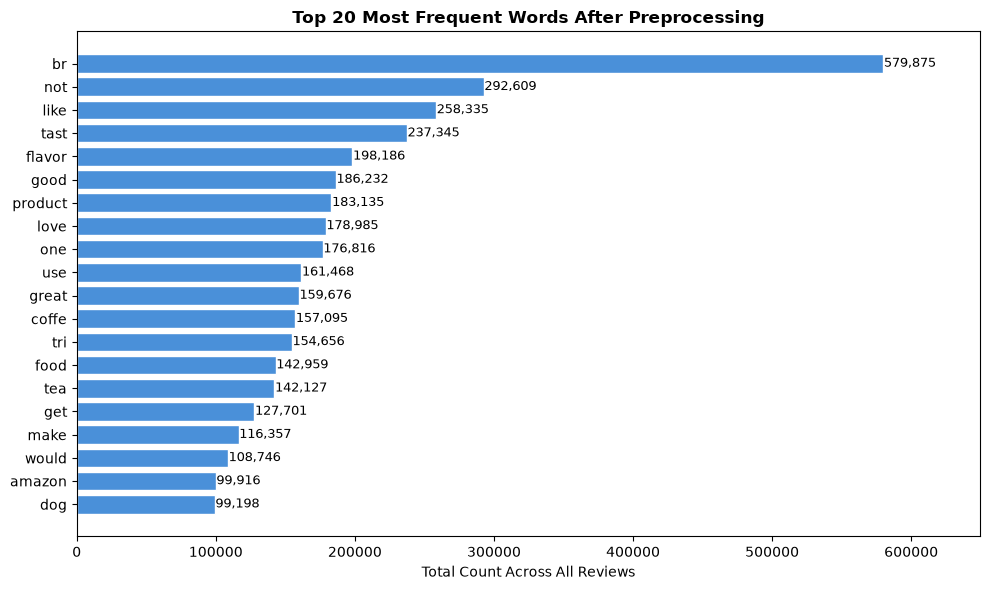

In [12]:
# Use CountVectorizer to get word frequencies across full corpus
# max_features=5000 to keep it fast
cv_eda = CountVectorizer(max_features=5000)
cv_eda.fit(corpus)

# Get vocabulary and their total counts
word_freq = pd.DataFrame({
    'word': cv_eda.get_feature_names_out(),
    'count': cv_eda.transform(corpus).toarray().sum(axis=0)
}).sort_values('count', ascending=False)

top20 = word_freq.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top20['word'][::-1], top20['count'][::-1],
               color='#4A90D9', edgecolor='white')

for bar, val in zip(bars, top20['count'][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9)

ax.set_title('Top 20 Most Frequent Words After Preprocessing', fontweight='bold')
ax.set_xlabel('Total Count Across All Reviews')
ax.set_xlim(0, top20['count'].max() * 1.12)
plt.tight_layout()
plt.savefig('viz4_top_words.png', bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
    # stratify=y ensures the same 84/16 class ratio in both train and test
)

print(f"Training set size : {X_train.shape[0]:,}")
print(f"Test set size     : {X_test.shape[0]:,}")
print()
print("Train class balance:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = "Positive" if u == 1 else "Negative"
    print(f"  {label}: {c:,} ({c/len(y_train)*100:.1f}%)")
print()
print("Everything saved and ready for modelling!")
print("Next: Naive Bayes  →  Logistic Regression  →  ANN")

Training set size : 420,651
Test set size     : 105,163

Train class balance:
  Negative: 65,658 (15.6%)
  Positive: 354,993 (84.4%)

Everything saved and ready for modelling!
Next: Naive Bayes  →  Logistic Regression  →  ANN


## Modeling Strategy
This project uses text preprocessing with stopword removal, stemming, and `CountVectorizer` to transform raw text into numeric features. Three classifiers are trained and evaluated: Logistic Regression, Multinomial Naive Bayes, and a shallow ANN. Because the dataset is imbalanced, the ANN training uses class weights to better handle the minority negative class.


In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression(max_iter=1000)

In [16]:
print(df['Sentiment'].value_counts())

Sentiment
1    443777
0     82037
Name: count, dtype: int64


In [17]:
log_reg.fit(X_train,y_train)

d:\machine-learning-part1\1- Machine Learning A-Z\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [18]:
y_pred=log_reg.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report,accuracy_score
print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

0.9294048286945028
              precision    recall  f1-score   support

           0       0.84      0.68      0.75     16379
           1       0.94      0.98      0.96     88784

    accuracy                           0.93    105163
   macro avg       0.89      0.83      0.85    105163
weighted avg       0.93      0.93      0.93    105163



In [21]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# MultinomialNB is better for text/count data than GaussianNB
# (GaussianNB assumes continuous data — CountVectorizer gives integer counts)
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("=== Naive Bayes ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}")
print()
print(classification_report(y_test, y_pred_nb, target_names=["Negative", "Positive"]))

=== Naive Bayes ===
Accuracy : 0.9028

              precision    recall  f1-score   support

    Negative       0.68      0.71      0.70     16379
    Positive       0.95      0.94      0.94     88784

    accuracy                           0.90    105163
   macro avg       0.81      0.83      0.82    105163
weighted avg       0.90      0.90      0.90    105163



In [ ]:
model=tf.keras.models.Sequential()


numpy.ndarray

In [25]:
model.add(tf.keras.layers.Dense(units=128,activation='relu'))
model.add(tf.keras.layers.Dense(units=64,activation='relu'))
model.add(tf.keras.layers.Dense(units=1,activation='sigmoid'))


In [29]:
from tensorflow.keras.callbacks import EarlyStopping


In [26]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [30]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [31]:
# Train ANN
# class_weight handles the imbalance (84% positive, 16% negative)
class_weight = {0: 5.0, 1: 1.0}  # give more importance to minority (negative) class

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=512,     # large batch size speeds up training on 420k rows
    validation_split=0.1,
    class_weight=class_weight,
    verbose=1,
    callbacks=[early_stop]

    
)

Epoch 1/20
740/740 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.9969 - loss: 0.0158 - val_accuracy: 0.9456 - val_loss: 0.3942
Epoch 2/20
740/740 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.9975 - loss: 0.0123 - val_accuracy: 0.9437 - val_loss: 0.3936
Epoch 3/20
740/740 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9979 - loss: 0.0108 - val_accuracy: 0.9448 - val_loss: 0.4095
Epoch 4/20
740/740 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9985 - loss: 0.0081 - val_accuracy: 0.9456 - val_loss: 0.4282
Epoch 5/20
740/740 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9986 - loss: 0.0076 - val_accuracy: 0.9448 - val_loss: 0.4555
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [32]:
# Predict with ANN
y_pred_ann_prob = model.predict(X_test)
y_pred_ann = (y_pred_ann_prob > 0.5).astype(int).flatten()

print("=== ANN ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_ann):.4f}")
print()
print(classification_report(y_test, y_pred_ann, target_names=["Negative", "Positive"]))


3287/3287 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
=== ANN ===
Accuracy : 0.9457

              precision    recall  f1-score   support

    Negative       0.81      0.84      0.83     16379
    Positive       0.97      0.96      0.97     88784

    accuracy                           0.95    105163
   macro avg       0.89      0.90      0.90    105163
weighted avg       0.95      0.95      0.95    105163



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy curve
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#4A90D9', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#E76F6F', linewidth=2, linestyle='--')
axes[0].set_title('ANN — Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss curve
axes[1].plot(history.history['loss'],     label='Train Loss', color='#4A90D9', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#E76F6F', linewidth=2, linestyle='--')
axes[1].set_title('ANN — Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Large gap between train and val = overfitting — fix with Dropout',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz_training_curve.png', bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models = [
    ('Naive Bayes',         y_pred_nb),
    ('Logistic Regression', y_pred),
    ('ANN',                 y_pred_ann)
]

for ax, (name, y_pred_model) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred_model)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                cbar=False, linewidths=0.5)
    acc = accuracy_score(y_test, y_pred_model)
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — All 3 Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Collect all metrics
results = {
    'Model':     ['Naive Bayes', 'Logistic Regression', 'ANN'],
    'Accuracy':  [accuracy_score(y_test, y_pred_nb),
                  accuracy_score(y_test, y_pred),
                  accuracy_score(y_test, y_pred_ann)],
    'Precision': [precision_score(y_test, y_pred_nb),
                  precision_score(y_test, y_pred),
                  precision_score(y_test, y_pred_ann)],
    'Recall':    [recall_score(y_test, y_pred_nb),
                  recall_score(y_test, y_pred),
                  recall_score(y_test, y_pred_ann)],
    'F1 Score':  [f1_score(y_test, y_pred_nb),
                  f1_score(y_test, y_pred),
                  f1_score(y_test, y_pred_ann)]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print()

# Grouped bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25
colors = ['#4A90D9', '#5BA85A', '#E76F6F']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (model, color) in enumerate(zip(results_df['Model'], colors)):
    vals = results_df[results_df['Model'] == model][metrics].values.flatten()
    bars = ax.bar(x + i*width, vals, width, label=model,
                  color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Naive Bayes vs Logistic Regression vs ANN',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('viz_model_comparison.png', bbox_inches='tight')
plt.show()